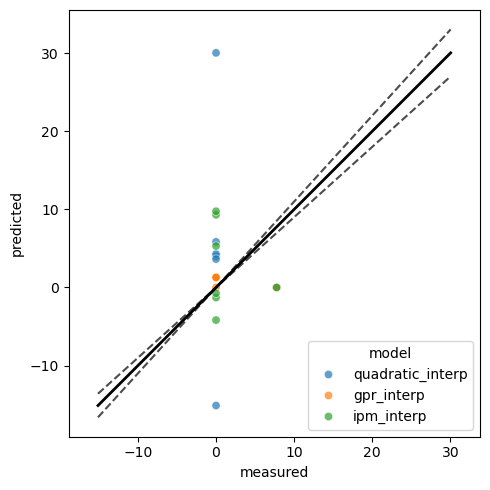

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TOLERANCE=0.1

metric = "d-"

models = [
    "quadratic_interp",
    "gpr_interp",
    "ipm_interp"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../{model}_2/ablation_results/{metric}_max_ablation.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(5, 5))

sns.scatterplot(
    data=df_all,
    x="measured",
    y="predicted",
    hue="model",
    alpha=0.7
)

lims = [
    min(df_all["measured"].min(), df_all["predicted"].min()),
    max(df_all["measured"].max(), df_all["predicted"].max())
]

x = np.linspace(lims[0], lims[1], 100)

# Ideal line
plt.plot(x, x, "k-", linewidth=2, label="Ideal")

# tolerance
plt.plot(x, (1.0 + TOLERANCE) * x, "k--", alpha=0.7, label="±10%")
plt.plot(x, (1.0 - TOLERANCE) * x, "k--", alpha=0.7)


plt.axis("equal")
plt.tight_layout()
plt.show()

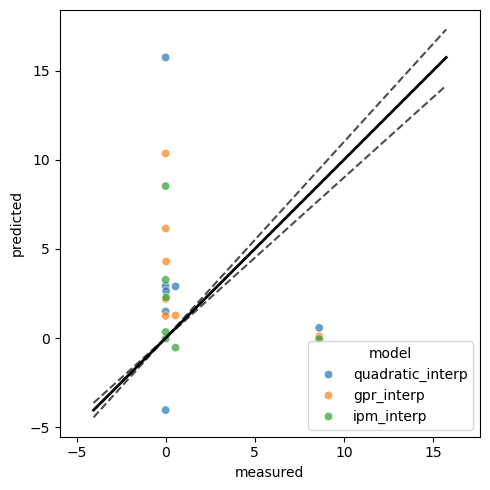

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TOLERANCE=0.1

metric = "d+"

models = [
    "quadratic_interp",
    "gpr_interp",
    "ipm_interp"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../{model}_2/ablation_results/{metric}_max_ablation.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(5, 5))

sns.scatterplot(
    data=df_all,
    x="measured",
    y="predicted",
    hue="model",
    alpha=0.7
)

lims = [
    min(df_all["measured"].min(), df_all["predicted"].min()),
    max(df_all["measured"].max(), df_all["predicted"].max())
]

x = np.linspace(lims[0], lims[1], 100)

# Ideal line
plt.plot(x, x, "k-", linewidth=2, label="Ideal")

# tolerance
plt.plot(x, (1.0 + TOLERANCE) * x, "k--", alpha=0.7, label="±10%")
plt.plot(x, (1.0 - TOLERANCE) * x, "k--", alpha=0.7)


plt.axis("equal")
plt.tight_layout()
plt.show()

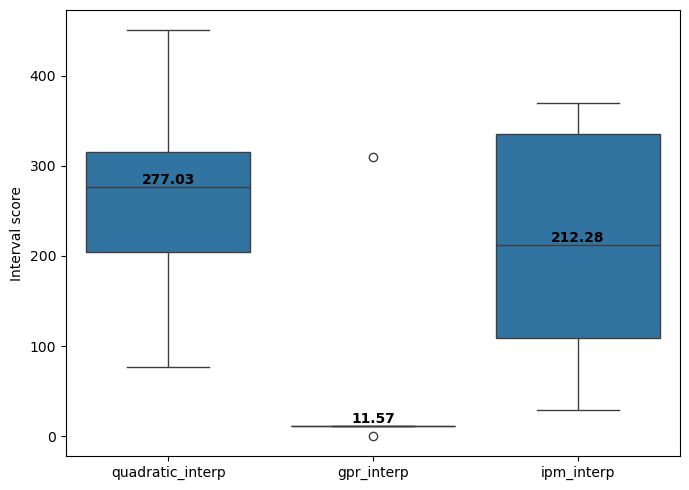

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "d-"

models = [
    "quadratic_interp",
    "gpr_interp",
    "ipm_interp"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../{model}_2/ablation_results/{metric}_max_ablation.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# enforce categorical order
df_all["model"] = pd.Categorical(df_all["model"], categories=models, ordered=True)

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df_all,
    x="model",
    y="interval_score",
    order=models
)

# compute medians in SAME order
medians = df_all.groupby("model", observed=False)["interval_score"].median().reindex(models)

# add labels aligned to x positions
for i, model in enumerate(models):
    y = medians.loc[model]
    ax.text(
        i, y,
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Interval score")
plt.xlabel("")
plt.tight_layout()
plt.show()

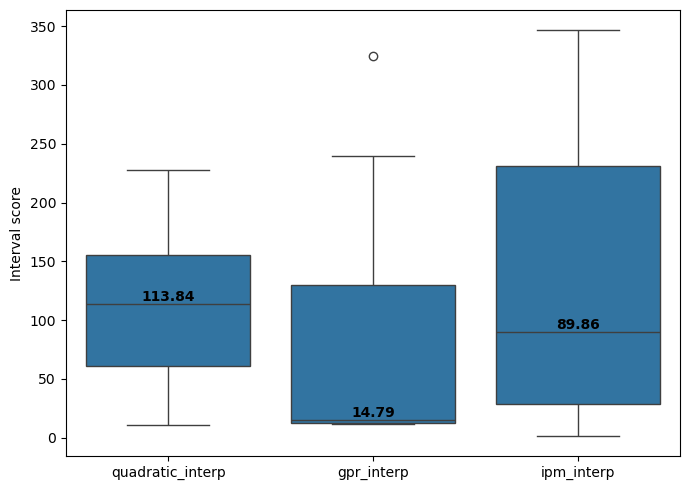

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "d+"

models = [
    "quadratic_interp",
    "gpr_interp",
    "ipm_interp"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../{model}_2/ablation_results/{metric}_max_ablation.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# enforce categorical order
df_all["model"] = pd.Categorical(df_all["model"], categories=models, ordered=True)

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df_all,
    x="model",
    y="interval_score",
    order=models
)

# compute medians in SAME order
medians = df_all.groupby("model", observed=False)["interval_score"].median().reindex(models)

# add labels aligned to x positions
for i, model in enumerate(models):
    y = medians.loc[model]
    ax.text(
        i, y,
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Interval score")
plt.xlabel("")
plt.tight_layout()
plt.show()

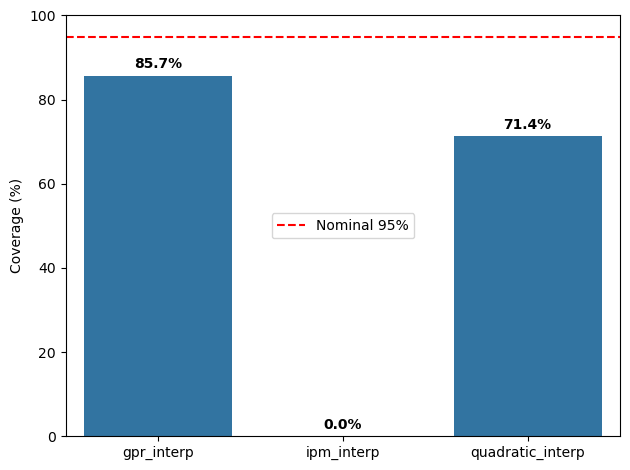

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "d-"

models = [
    "quadratic_interp",
    "gpr_interp",
    "ipm_interp"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../{model}_2/ablation_results/{metric}_max_ablation.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

coverage = (
    df_all.groupby("model")["within_pi"]
    .mean()              # True=1, False=0
    .mul(100)            # convert to %
    .reset_index(name="coverage")
)

ax = sns.barplot(
    data=coverage,
    x="model",
    y="coverage"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")

plt.ylabel("Coverage (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.axhline(95, color="red", linestyle="--", label="Nominal 95%")
plt.legend()
plt.tight_layout()
plt.show()

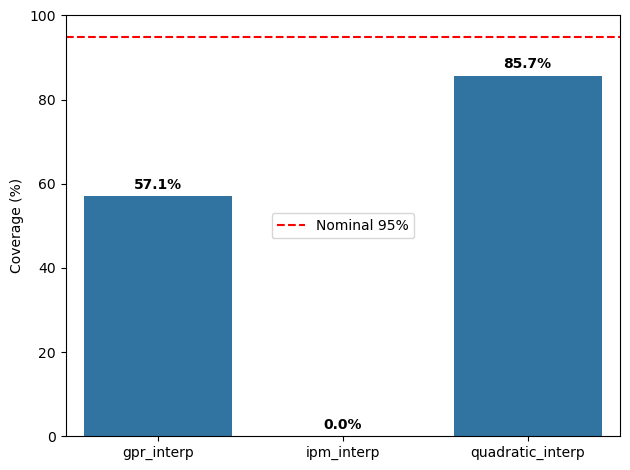

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "d+"

models = [
    "quadratic_interp",
    "gpr_interp",
    "ipm_interp"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../{model}_2/ablation_results/{metric}_max_ablation.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

coverage = (
    df_all.groupby("model")["within_pi"]
    .mean()              # True=1, False=0
    .mul(100)            # convert to %
    .reset_index(name="coverage")
)

ax = sns.barplot(
    data=coverage,
    x="model",
    y="coverage"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")

plt.ylabel("Coverage (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.axhline(95, color="red", linestyle="--", label="Nominal 95%")
plt.legend()
plt.tight_layout()
plt.show()